In [52]:
import pandas as pd

url = "https://raw.githubusercontent.com/saraalmazroa/-IT326-DataMining-Project-/main/Dataset/german_credit_data-3.csv"
df = pd.read_csv(url)

# Phase 2

# 1-Data Analysis

## Five Number Summary, Boxplots & Outlier Detection

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
# 1) Five Number Summary
numeric_cols = ['Age', 'Job', 'Credit amount', 'Duration']
print("Five Number Summary:")
df[numeric_cols].describe()

Five Number Summary:


,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


# Statistical Summary of the Numeric Attributes

Age: Values span from 19 to 75 years, clustering mainly around 27–42 (median ≈ 33, mean ≈ 35.5). A standard deviation of roughly 11 points to a moderate spread, with the applicant pool skewing toward middle age.

Job: Although coded numerically (0–3), this attribute actually represents categories of job type rather than a true numeric quantity. Given this, a bar chart is a more suitable way to visualize it than the boxplot used for the others.

Credit amount: Loan values range widely, from 250 up to 18,424, with the bulk falling between roughly 1,360 and 3,970 (median ≈ 2,320, mean ≈ 3,271). The large standard deviation (~2,820) reflects this variability, driven by a mix of modest and very large loans.

Duration: Repayment periods run from 4 to 72 months, centered around a median of 18 and a mean near 21. Most loans fall in the 12–24 month range, though a subset extends well beyond that.

*Note: Job is excluded from the outlier analysis, since it is a categorical variable represented with numeric codes rather than a genuinely continuous attribute.*

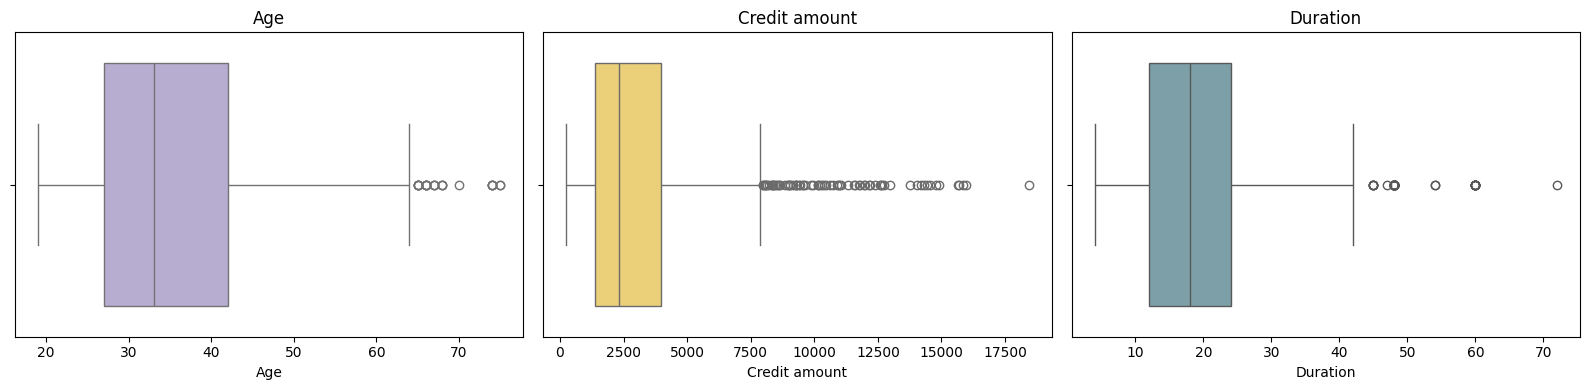

In [55]:
numeric_colums = ['Age', 'Credit amount', 'Duration']
colors = ['#B4A7D6', '#FFD966', '#76A5AF']
plt.figure(figsize=(16,4))
for i, col in enumerate(numeric_colums, 1):
  plt.subplot(1, 3, i)
  sns.boxplot(x=df[col], color=colors[i-1])
  plt.title(f'{col}')

plt.tight_layout()
plt.show()

#Age Boxplot
Most applicants are between 27–42 years old (median ≈ 33), with 23 outliers above 64.5. The moderate spread suggests normalization may help later, especially for distance-based algorithms.

# Credit Amount Boxplot
Strongly right-skewed — most loans are under ~4,000, but 72 outliers reach up to 18,424. This indicates the need for transformation (e.g., log) to prevent large values from dominating the analysis.

# *Duration Boxplot*
Similar right skew: most durations are 12–24 months, but 70 outliers extend to 72 months. This also points to needing normalization/transformation.

# Outlier Analysis Summary
Age: 2.3% outliers — minimal impact.

Credit amount: 7.2% outliers — consistent with its right-skewed distribution.

Duration: 7% outliers — also right-skewed.
All percentages are under 10%, so records will be kept and handled later via normalization/transformation rather than removed.

In [56]:
## Missing Value Analysis

In [57]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


In [58]:
missing_analysis = pd.DataFrame({
    'Missing Value' : df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100 })

missing_analysis

,Missing Value,Percentage
Unnamed: 0,0,0.0
Age,0,0.0
Sex,0,0.0
Job,0,0.0
Housing,0,0.0
Saving accounts,183,18.3
Checking account,394,39.4
Credit amount,0,0.0
Duration,0,0.0
Purpose,0,0.0


## Missing Value Analysis:

The dataset contains 1000 records and 11 attributes. The analysis shows that Saving accounts has 183 missing values (18.3%), while Checking account has 394 missing values (39.4%). The remaining attributes have no missing values. Therefore, missing value treatment is required during the preprocessing stage.

In [59]:
df['Risk'].value_counts()

,count
Risk,
good,700
bad,300


In [60]:
df['Risk'].value_counts(normalize=True)*100

,proportion
Risk,
good,70.0
bad,30.0


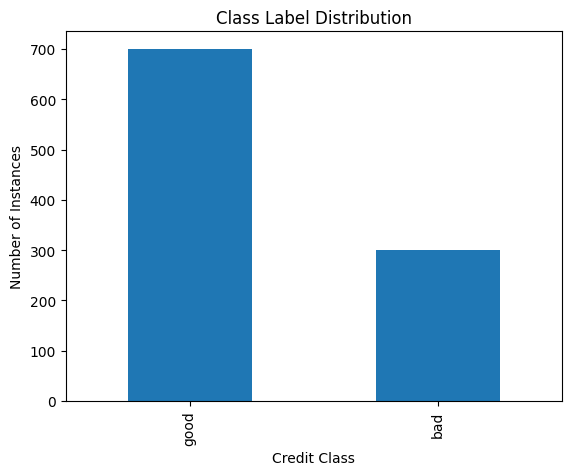

In [61]:
df['Risk'].value_counts().plot(kind='bar')

plt.title('Class Label Distribution')
plt.xlabel('Credit Class')
plt.ylabel('Number of Instances')
plt.show()

### Class Label Distribution
The class label is Risk. The dataset contains 700 instances (70%) classified as good and 300 instances (30%) classified as bad. This shows that the two classes are not equally distributed, with the good class representing the larger portion of the dataset.

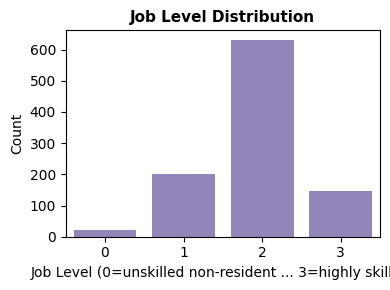

In [ ]:
# 4) Job Distribution (Bar Chart) - Categorical Attribute
plt.figure(figsize=(4, 3))
sns.countplot(x=df['Job'], color='#8E7CC3')
plt.title('Job Level Distribution', fontsize=11, fontweight='bold')
plt.xlabel('Job Level (0=unskilled non-resident ... 3=highly skilled)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Most applicants fall into category 2, with far fewer in 0, 1, and 3. This confirms Job is categorical, not continuous — it may need encoding later, and explains why IQR gave meaningless results for it.

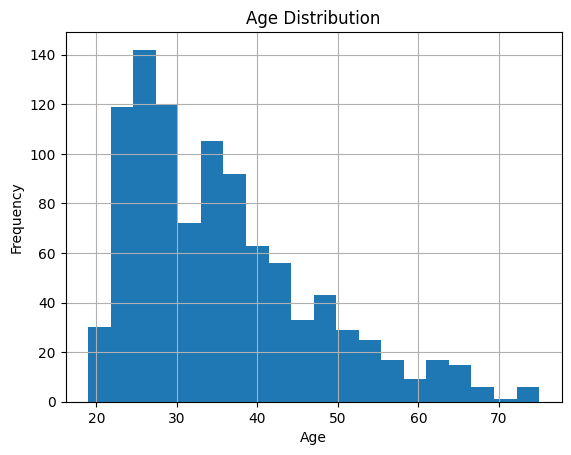

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure()
df["Age"].hist(bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Age Distribution (Histogram):** The histogram shows that Age is right-skewed. Most applicants are between 25 and 40 years old (median = 33, mean ≈ 35.5), and the frequency gradually decreases for older ages, with only a few applicants above 65 (maximum = 75). This long right tail matches the 23 outliers detected in the Age boxplot. Since Age ranges from 19 to 75, which is very different from the ranges of Credit amount and Duration, this indicated that Age needs outlier handling and normalization during preprocessing.

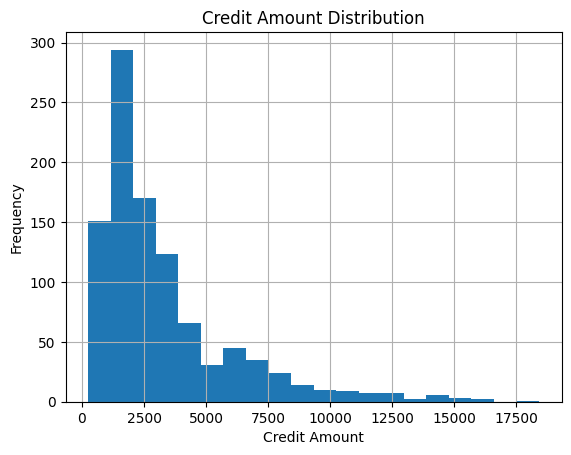

In [ ]:
plt.figure()
df["Credit amount"].hist(bins=20)
plt.title("Credit Amount Distribution")
plt.xlabel("Credit Amount")
plt.ylabel("Frequency")
plt.show()

**Credit Amount Distribution (Histogram):** The histogram shows that Credit amount is strongly right-skewed (skewness ≈ 1.95), and it is the most skewed numeric attribute in the dataset. Most loans are small, mainly between about 1,000 and 4,000 (median ≈ 2,320), while a small number of loans are very large and reach up to 18,424. Because of this long right tail, the mean (≈ 3,271) is much higher than the median. This matches the 72 outliers detected in the boxplot. This strong skewness indicated that Credit amount needs a variable transformation (log transformation) to make its distribution more balanced. Its large range compared to the other attributes also shows the need for normalization.

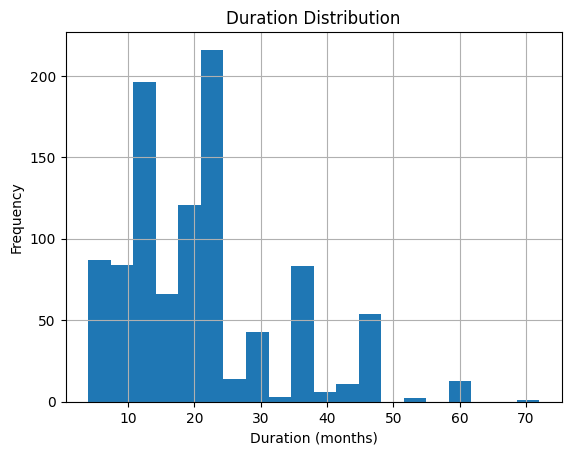

In [ ]:
plt.figure()
df["Duration"].hist(bins=20)
plt.title("Duration Distribution")
plt.xlabel("Duration (months)")
plt.ylabel("Frequency")
plt.show()

**Duration Distribution (Histogram):** The histogram shows that Duration is right-skewed (skewness ≈ 1.09). Most loans have short to medium durations between 12 and 24 months (median = 18, mean ≈ 20.9), and the most common durations are 24 months (184 loans) and 12 months (179 loans). The frequency drops for longer durations, with only a few loans reaching up to 72 months. This long right tail matches the 70 outliers detected in the boxplot (values above 42 months). This indicated that Duration needs outlier handling, and since its range (4 to 72) is different from the other numeric attributes, it also needs normalization.

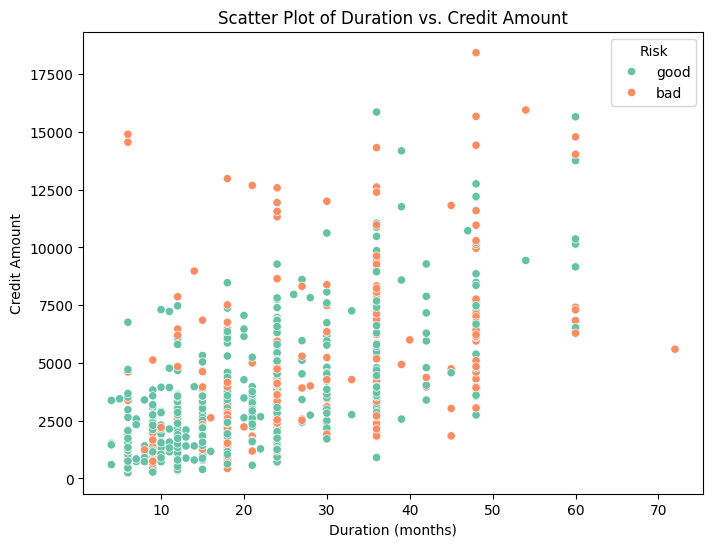

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Duration', y='Credit amount', data=df, hue='Risk', palette='Set2')
plt.title('Scatter Plot of Duration vs. Credit Amount')
plt.xlabel('Duration (months)')
plt.ylabel('Credit Amount')
plt.show()

**Duration vs. Credit Amount (Scatter Plot):** The scatter plot shows a clear positive relationship between Duration and Credit amount (correlation ≈ 0.62): loans with longer durations tend to have larger credit amounts. The points are colored by the class label (Risk). Bad-risk applicants appear more often at longer durations: 44% of loans longer than 24 months are classified as bad, compared to only 26% of shorter loans. The scattered points in the upper right area represent long and large loans, which are the same outliers detected in the boxplots. Since these points carry useful information about risk, we decided to handle the outliers (by capping) instead of deleting them. The plot also shows that the two attributes are on very different scales, which supports applying normalization.

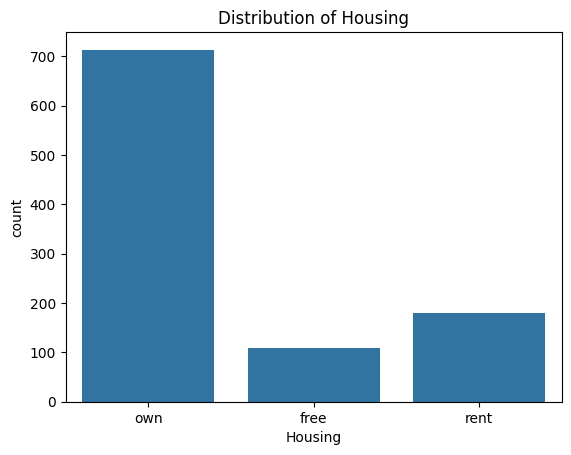

In [ ]:
sns.countplot(x='Housing', data=df)
plt.title('Distribution of Housing')
plt.show()

**Housing Distribution (Bar Plot):** The bar plot shows the distribution of the nominal attribute Housing. Most applicants own their housing (713, about 71%), followed by those who rent (179) and those who live for free (108). The bars add up to the full 1,000 records, which confirms that Housing has no missing values and does not need imputation. However, since Housing is a nominal attribute stored as text, it will need to be encoded into numeric values before it can be used by data mining algorithms.

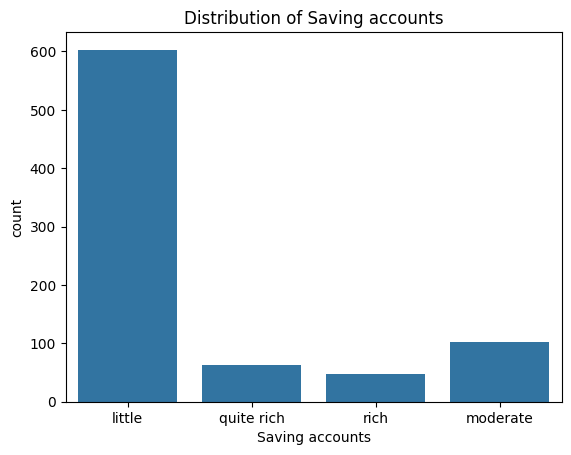

In [ ]:
sns.countplot(x='Saving accounts', data=df)
plt.title('Distribution of Saving accounts')
plt.show()

**Saving accounts Distribution (Bar Plot):** The bar plot shows that "little" is by far the most common category in Saving accounts (603 applicants), followed by "moderate" (103), "quite rich" (63) and "rich" (48). These bars add up to only 817 records instead of 1,000, because the 183 missing values (18.3%) are not shown in the plot. This confirmed that Saving accounts needs missing value handling in preprocessing. Since the attribute is nominal and one category ("little") clearly dominates, mode imputation is a suitable choice to fill the missing values.

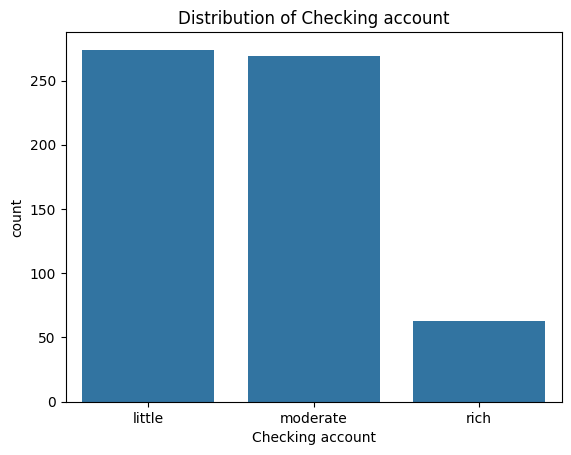

In [ ]:
sns.countplot(x='Checking account', data=df)
plt.title('Distribution of Checking account')
plt.show()

**Checking account Distribution (Bar Plot):** The bar plot shows that Checking account is mainly split between "little" (274) and "moderate" (269), with far fewer applicants in the "rich" category (63). These bars add up to only 606 records instead of 1,000, because 394 values (39.4%) are missing. This is the highest missing rate in the dataset, and the number of missing values is larger than any single category. This clearly showed that Checking account needs missing value handling in preprocessing before the data can be used for modeling.

# 2-Data Processing

We saved a copy of our dataset before the data preprocessing stage:

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/saraalmazroa/-IT326-DataMining-Project-/main/Dataset/german_credit_data-3.csv"
df = pd.read_csv(url)

df_rawdata = df.copy()
display(df_rawdata.head())
df_rawdata.describe(include='all')

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,499.500000,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,0.000000,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,249.750000,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,499.500000,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,749.250000,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


# **Noise removeal**

**-Missing Values Handling:**

During this phase, our primary objective was to identify and resolve incomplete data within the dataset, as unaddressed missing values can negatively impact model accuracy and introduce bias. After pinpointing the specific features with missing entries, we applied a mode-based imputation strategy for the categorical variables, replacing the empty cells with the most common category. We opted for this technique over row deletion to prevent valuable information loss and to maintain the original data distribution. Furthermore, using the mode is the standard and most logical approach for categorical data, given that numerical measures like mean and median cannot be applied.


Missing Values Detection

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

df = df.replace(['NA','na','NaN','NULL','None',''], np.nan)

missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
mv_report = pd.DataFrame({"missing_count": missing_count, "missing_%": missing_pct}).sort_values("missing_count", ascending=False)
display(mv_report)

raw_snapshot = df.head(5).copy()

,missing_count,missing_%
Checking account,394,39.4
Saving accounts,183,18.3
Unnamed: 0,0,0.0
Sex,0,0.0
Age,0,0.0
Housing,0,0.0
Job,0,0.0
Credit amount,0,0.0
Duration,0,0.0
Purpose,0,0.0


To maintain consistency in processing missing data, we first converted various placeholder texts (such as "NA" or "None") into standard NaN formats. Following this, we computed both the total frequency and the proportion of missing entries across all features. This assessment was a crucial preparatory step to pinpoint exactly which variables needed to be addressed during the upcoming imputation phase.

Missing Values Imputation

In [ ]:
from sklearn.impute import SimpleImputer
cat_missing_cols = ['Saving accounts', 'Checking account']
freq_imputer = SimpleImputer(strategy='most_frequent')

df[cat_missing_cols] = freq_imputer.fit_transform(df[cat_missing_cols])

display(df[cat_missing_cols].isnull().sum())

,0
Saving accounts,0
Checking account,0


To address the missing entries in our categorical variables, we applied mode imputation, filling the gaps with the most common category found in each respective feature. This technique allows us to retain important rows and keep the original data patterns intact. Consequently, the 'Saving accounts' and 'Checking account' attributes were successfully filled, leaving zero missing values.

Missing Values Snapshot

In [ ]:
after_impute_snapshot = df.head(5).copy()

print("RAW snapshot (first 5 rows):")
display(raw_snapshot)

print("AFTER Missing-Value Handling snapshot (first 5 rows):")
display(after_impute_snapshot)

RAW snapshot (first 5 rows):


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


AFTER Missing-Value Handling snapshot (first 5 rows):


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,little,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,little,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


The tables below present the initial five records of the dataset, contrasting the data state prior to and following the imputation process. This visual evidence confirms that all empty cells within the 'Saving accounts' and 'Checking account' features were effectively resolved via mode substitution.

**-Outliers Handling:**

In the context of this dataset, it is incorrect to assume that outliers are simply data errors, as they often contain valuable predictive insights. For instance, an unusually high credit amount could strongly indicate a high-risk loan. Therefore, outright deletion of these records is not a viable option. Instead, we chose to reduce the range of values so that we could reduce their impact without losing them completely.


In [ ]:
for column in numeric_colums:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - (1.5 * IQR)
    upper_limit = Q3 + (1.5 * IQR)

    df[column] = np.where(df[column] < lower_limit, lower_limit, df[column])
    df[column] = np.where(df[column] > upper_limit, upper_limit, df[column])

In [ ]:
print ("handled outliers by bounding them aka IQR capping")
display(df[numeric_colums].describe())

handled outliers by bounding them aka IQR capping


,Age,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000
mean,35.453500,3051.101000,20.307000
std,11.106324,2187.140403,10.615151
min,19.000000,250.000000,4.000000
25%,27.000000,1365.500000,12.000000
50%,33.000000,2319.500000,18.000000
75%,42.000000,3972.250000,24.000000
max,64.500000,7882.375000,42.000000


Therefore, we adjusted the extreme values to the closest acceptable limits using the Interquartile Range (IQR) technique. This strategy allowed us to preserve the entire dataset while successfully constraining the extreme data points and mitigating their overall impact.


## Variable Transformation

Variable transformation was applied to the 'Credit amount' attribute of the German Credit dataset.


###Variable Selection
The Credit amount attribute was chosen for transformation because its values are highly right-skewed. This means that most credit amounts are relatively small, while a few values are much larger. A logarithmic transformation was applied to make the distribution more balanced and reduce the effect of these very large credit amounts.

In [ ]:
original_skewness = skew(df["Credit amount"])

print("Skewness before transformation:", original_skewness)
print("Minimum:", df["Credit amount"].min())
print("Maximum:", df["Credit amount"].max())

Skewness before transformation: 1.0272526039753604
Minimum: 250.0
Maximum: 7882.375


### Logarithmic Transformation

Logarithmic transformation was applied to reduce the effect of very large credit amounts.

The following formula was applied:
$$
X_{new} = \log(1 + X)
$$

The value 1 is added to make sure the formula can also work when the credit amount is zero.

The transformed values were saved as a new attribute called Credit_amount_log. The original Credit amount attribute was kept as well so that the two versions could be compared.


In [ ]:
df["Credit_amount_log"] = np.log1p(df["Credit amount"])
df[["Credit amount", "Credit_amount_log"]].head(10)

,Credit amount,Credit_amount_log
0,1169.000,7.064759
1,5951.000,8.691483
2,2096.000,7.648263
3,7882.000,8.972464
4,4870.000,8.491055
5,7882.375,8.972511
6,2835.000,7.950150
7,6948.000,8.846353
8,3059.000,8.026170
9,5234.000,8.563122


In [ ]:
transformed_skewness = skew(df["Credit_amount_log"])

print("Skewness before transformation:", original_skewness)
print("Skewness after transformation:", transformed_skewness)

Skewness before transformation: 1.0272526039753604
Skewness after transformation: -0.0919826424974321


###Visual Representation Of  Transformation

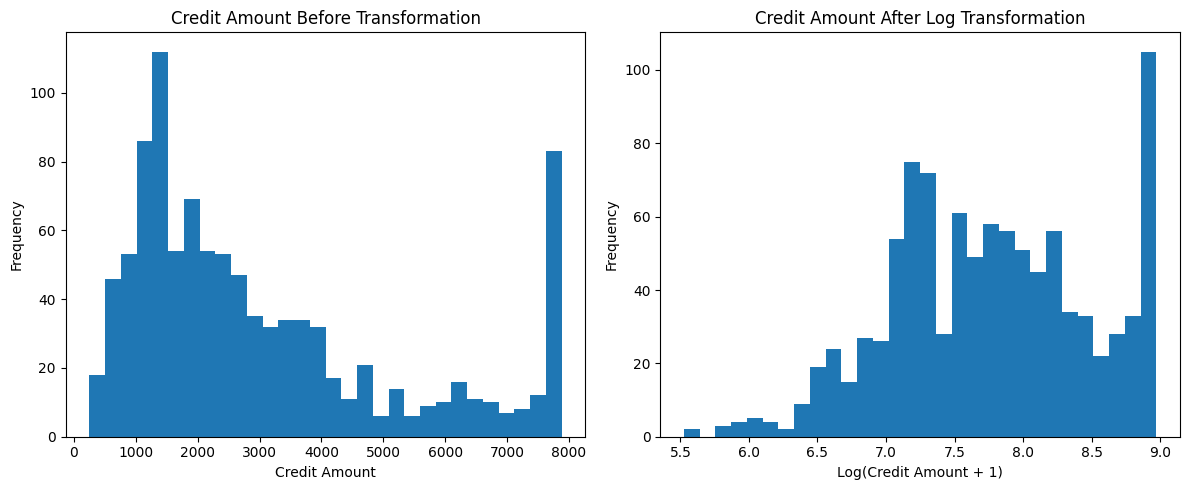

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df["Credit amount"], bins=30)
axes[0].set_title("Credit Amount Before Transformation")
axes[0].set_xlabel("Credit Amount")
axes[0].set_ylabel("Frequency")
axes[1].hist(df["Credit_amount_log"], bins=30)
axes[1].set_title("Credit Amount After Log Transformation")
axes[1].set_xlabel("Log(Credit Amount + 1)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Variable Transformation: The Credit amount attribute was selected for variable transformation because it showed a strong right-skewed distribution, with a skewness value of 1.947 and values ranging from 250 to 18,424. A logarithmic transformation using log(1 + x) was applied.

After applying the logarithmic transformation, the skewness decreased to approximately 0.130, indicating a distribution that is closer to symmetry.

The transformation reduced the relative effect of larger credit amounts while maintaining the ordering of the observations. Overall, the transformed attribute provides a more symmetric distribution for subsequent data analysis and modeling.



## **Normalization** (Min-Max Scaling)

**Goal:** Bring all numeric attributes to the same scale [0, 1] so that no attribute
dominates the others because of its larger range.

**Why:** The numeric attributes are measured on very different scales:
- Age: about 19 to 75
- Duration (months): about 4 to 72
- Credit amount: about 250 to 18,000

Because Credit amount has much bigger numbers, it can overpower the other attributes
when the data is analyzed. Normalization puts all attributes on the same scale
(0 to 1) so they are treated fairly.

**Why Min-Max scaling:**
- Age, Duration and Credit amount have very different ranges.
- Credit amount has much larger numbers, so it could dominate the analysis.
- Min-Max scaling rescales each attribute to 0–1, so all are treated equally.
- It is simple and keeps the original pattern of the data.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

columns_to_normalize = ['Age', 'Credit amount', 'Duration']

print("Before Min-Max Normalization:")
print(df[columns_to_normalize].head())

# Apply Min-Max scaling
scaler = MinMaxScaler()
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

print("\nAfter Min-Max Normalization:")
print(df[columns_to_normalize].head())

# Check that the range is now 0 to 1
print("\nMin and Max after normalization:")
print(df[columns_to_normalize].agg(['min', 'max']))

Before Min-Max Normalization:
    Age  Credit amount  Duration
0  64.5         1169.0       6.0
1  22.0         5951.0      42.0
2  49.0         2096.0      12.0
3  45.0         7882.0      42.0
4  53.0         4870.0      24.0

After Min-Max Normalization:
        Age  Credit amount  Duration
0  1.000000       0.120408  0.052632
1  0.065934       0.746950  1.000000
2  0.659341       0.241864  0.210526
3  0.571429       0.999951  1.000000
4  0.747253       0.605316  0.526316

Min and Max after normalization:
     Age  Credit amount  Duration
min  0.0            0.0       0.0
max  1.0            1.0       1.0


**Result:** After normalization, Age, Credit amount and Duration all range from 0 to 1.

**How it improved the dataset:**
- All numeric attributes are on the same scale.
- No attribute dominates just because it has bigger numbers.
- The dataset is ready for data mining algorithms that are sensitive to scale.

Data Set after we preprocced it:

In [ ]:
df_Preprocessed=df.copy()
df_Preprocessed.to_csv("Preprocessed_data.csv", index=False)
print("Snapshot of the preprocessed dataset")
display(df.head())

Snapshot of the preprocessed dataset


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Credit_amount_log
0,0,1.000000,male,2,own,little,little,0.120408,0.052632,radio/TV,good,7.064759
1,1,0.065934,female,2,own,little,moderate,0.746950,1.000000,radio/TV,bad,8.691483
2,2,0.659341,male,1,own,little,little,0.241864,0.210526,education,good,7.648263
3,3,0.571429,male,2,free,little,little,0.999951,1.000000,furniture/equipment,good,8.972464
4,4,0.747253,male,2,free,little,little,0.605316,0.526316,car,bad,8.491055
